# 1. GENERAR DATASET

In [ ]:
import pandas as pd
import glob
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
folder_path = "/content/drive/MyDrive/RETO3-SistemaGestiónMicrored/objetivo2/PV_MaximumPowerPredictor/PV_MaximumPowerPredictor"

files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

In [ ]:
files

['Eugene_aSiTandem72-46_cleaned.csv',
 'Eugene_aSiMicro03036_cleaned.csv',
 'Cocoa_aSiMicro03036_cleaned.csv',
 'Cocoa_mSi0166_cleaned.csv',
 'Cocoa_CIGS8-001_cleaned.csv',
 'Cocoa_mSi460A8_cleaned.csv',
 'Cocoa_CIGS39017_cleaned.csv',
 'Cocoa_mSi0188_cleaned.csv',
 'Cocoa_HIT05667_cleaned.csv',
 'Cocoa_aSiTandem72-46_cleaned.csv',
 'Cocoa_xSi12922_cleaned.csv',
 'Cocoa_CdTe75638_cleaned.csv',
 'Eugene_aSiTriple28324_cleaned.csv',
 'Cocoa_aSiTriple28324_cleaned.csv',
 'Eugene_CIGS8-001_cleaned.csv',
 'Golden_aSiTriple28325_cleaned.csv',
 'Golden_aSiTandem90-31_cleaned.csv',
 'Golden_aSiMicro03038_cleaned.csv',
 'Golden_CIGS1-001_cleaned.csv',
 'Golden_CdTe75669_cleaned.csv',
 'Eugene_xSi12922_cleaned.csv',
 'Golden_xSi11246_cleaned.csv',
 'Golden_CIGS39013_cleaned.csv',
 'Eugene_mSi0166_cleaned.csv',
 'Eugene_mSi0188_cleaned.csv',
 'Golden_HIT05662_cleaned.csv',
 'Eugene_CdTe75638_cleaned.csv',
 'Golden_mSi460BB_cleaned.csv',
 'Eugene_CIGS39017_cleaned.csv',
 'Golden_mSi0251_cleaned.cs

In [ ]:
dfs = []

for archivo in files:

    nombre = os.path.basename(archivo).replace(".csv","")

    partes = nombre.split("_")

    parque_id = partes[0]              # Cocoa / Golden / Eugene
    panel_id = "_".join(partes[1:])    # tipo de panel

    df = pd.read_csv(os.path.join(folder_path, archivo))

    # eliminar timestamp
    df = df.drop(columns=["Time Stamp (local standard time) yyyy-mm-ddThh:mm:ss"], errors="ignore")

    # añadir columnas
    df["parque_id"] = parque_id
    df["panel_id"] = panel_id

    # mover columnas al inicio
    cols = ["parque_id","panel_id"] + [c for c in df.columns if c not in ["parque_id","panel_id"]]
    df = df[cols]

    dfs.append(df)

dataset_total = pd.concat(dfs, ignore_index=True)

print(dataset_total.shape)
dataset_total.head()

(1025599, 12)


,parque_id,panel_id,POA irradiance CMP22 pyranometer (W/m2),PV module back surface temperature (degC),Pmp (W),Dry bulb temperature (degC),Relative humidity (%RH),Atmospheric pressure (mb),Precipitation (mm) accumulated daily total,Direct normal irradiance (W/m2),Global horizontal irradiance (W/m2),Diffuse horizontal irradiance (W/m2)
0,Eugene,aSiTandem72-46_cleaned,22.7,4.9,0.8391,3.9,86.0,989.1,18.8,0.0,28.0,28.3
1,Eugene,aSiTandem72-46_cleaned,31.2,5.0,1.1929,3.9,85.6,989.1,18.8,0.1,37.4,37.9
2,Eugene,aSiTandem72-46_cleaned,33.8,5.2,1.2934,3.9,85.9,989.3,18.8,0.1,41.1,41.8
3,Eugene,aSiTandem72-46_cleaned,29.6,5.1,1.1089,3.9,85.9,989.2,18.8,0.1,35.7,36.2
4,Eugene,aSiTandem72-46_cleaned,32.7,5.2,1.2329,3.9,85.4,989.2,18.9,0.1,40.2,40.8


# 2. EXPLORAR LOS DATOS

In [ ]:
dataset_total["parque_id"].value_counts() # Comprobar num de parques y paneles

,count
parque_id,
Eugene,473348
Cocoa,421664
Golden,130587


In [ ]:
dataset_total["panel_id"].nunique()

22

In [ ]:
sorted(dataset_total["panel_id"].unique())

['CIGS1-001_cleaned',
 'CIGS39013_cleaned',
 'CIGS39017_cleaned',
 'CIGS8-001_cleaned',
 'CdTe75638_cleaned',
 'CdTe75669_cleaned',
 'HIT05662_cleaned',
 'HIT05667_cleaned',
 'aSiMicro03036_cleaned',
 'aSiMicro03038_cleaned',
 'aSiTandem72-46_cleaned',
 'aSiTandem90-31_cleaned',
 'aSiTriple28324_cleaned',
 'aSiTriple28325_cleaned',
 'mSi0166_cleaned',
 'mSi0188_cleaned',
 'mSi0247_cleaned',
 'mSi0251_cleaned',
 'mSi460A8_cleaned',
 'mSi460BB_cleaned',
 'xSi11246_cleaned',
 'xSi12922_cleaned']

In [ ]:
pd.crosstab(dataset_total["parque_id"], dataset_total["panel_id"])

panel_id,CIGS1-001_cleaned,CIGS39013_cleaned,CIGS39017_cleaned,CIGS8-001_cleaned,CdTe75638_cleaned,CdTe75669_cleaned,HIT05662_cleaned,HIT05667_cleaned,aSiMicro03036_cleaned,aSiMicro03038_cleaned,...,aSiTriple28324_cleaned,aSiTriple28325_cleaned,mSi0166_cleaned,mSi0188_cleaned,mSi0247_cleaned,mSi0251_cleaned,mSi460A8_cleaned,mSi460BB_cleaned,xSi11246_cleaned,xSi12922_cleaned
parque_id,,,,,,,,,,,,,,,,,,,,,
Cocoa,0,0,34775,38939,39080,0,0,38377,39037,0,...,38485,0,36765,39102,0,0,38929,0,0,38989
Eugene,0,0,42674,43146,42248,0,0,43271,43343,0,...,42705,0,43268,43127,0,0,43115,0,0,43185
Golden,12011,11437,0,0,0,11953,11876,0,0,12148,...,0,11445,0,0,11912,11887,0,11919,11929,0


In [ ]:
dataset_total.isna().sum()

,0
parque_id,0
panel_id,0
POA irradiance CMP22 pyranometer (W/m2),0
PV module back surface temperature (degC),0
Pmp (W),0
Dry bulb temperature (degC),0
Relative humidity (%RH),0
Atmospheric pressure (mb),0
Precipitation (mm) accumulated daily total,0
Direct normal irradiance (W/m2),0


In [ ]:
import numpy as np
dataset_total = dataset_total.replace(-9999, np.nan)
dataset_total = dataset_total.dropna()

In [ ]:
dataset_total.describe()

,POA irradiance CMP22 pyranometer (W/m2),PV module back surface temperature (degC),Pmp (W),Dry bulb temperature (degC),Relative humidity (%RH),Atmospheric pressure (mb),Precipitation (mm) accumulated daily total,Direct normal irradiance (W/m2),Global horizontal irradiance (W/m2),Diffuse horizontal irradiance (W/m2)
count,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000
mean,419.073269,29.467554,33.109488,19.317690,61.454120,989.396137,0.769051,390.631045,380.965122,141.156003
std,346.843670,13.214163,37.509871,8.305093,19.398323,56.567985,3.476576,387.059795,298.460348,102.224197
min,19.900000,-18.900000,0.139500,-16.100000,4.600000,797.900000,0.000000,-4.700000,-1.700000,-1.700000
25%,112.900000,19.300000,6.666200,12.900000,48.800000,997.600000,0.000000,0.900000,125.400000,67.900000
50%,295.100000,29.300000,20.023850,20.700000,62.900000,1006.300000,0.000000,299.600000,288.000000,107.800000
75%,733.200000,39.500000,46.096500,25.900000,76.600000,1015.000000,0.000000,802.400000,612.300000,187.200000
max,1443.500000,73.200000,284.718900,39.100000,100.000000,1030.700000,59.200000,1069.000000,1406.600000,969.000000


Columnas numéricas utilizadas:
Index(['POA irradiance CMP22 pyranometer (W/m2)',
       'PV module back surface temperature (degC)', 'Pmp (W)',
       'Dry bulb temperature (degC)', 'Relative humidity (%RH)',
       'Atmospheric pressure (mb)',
       'Precipitation (mm) accumulated daily total',
       'Direct normal irradiance (W/m2)',
       'Global horizontal irradiance (W/m2)',
       'Diffuse horizontal irradiance (W/m2)'],
      dtype='object')

===== VARIABLE: POA irradiance CMP22 pyranometer (W/m2) =====
normal     -> KS=0.1404, p=0.0000e+00
exponential -> KS=0.0836, p=0.0000e+00
uniform    -> KS=0.3186, p=0.0000e+00
laplace    -> KS=0.1945, p=0.0000e+00
cauchy     -> KS=0.2305, p=0.0000e+00
gamma      -> KS=0.0816, p=0.0000e+00
lognormal  -> KS=0.0883, p=0.0000e+00
 Mejor distribución: normal (p=0.0000e+00)

===== VARIABLE: PV module back surface temperature (degC) =====
normal     -> KS=0.0338, p=0.0000e+00
exponential -> KS=0.3811, p=0.0000e+00
uniform    -> KS=0.2462, p=0.

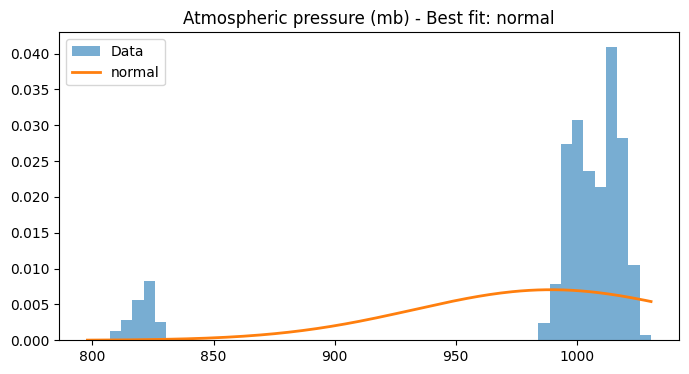

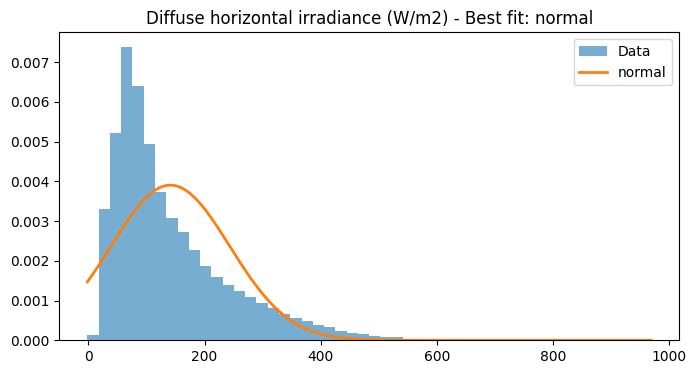

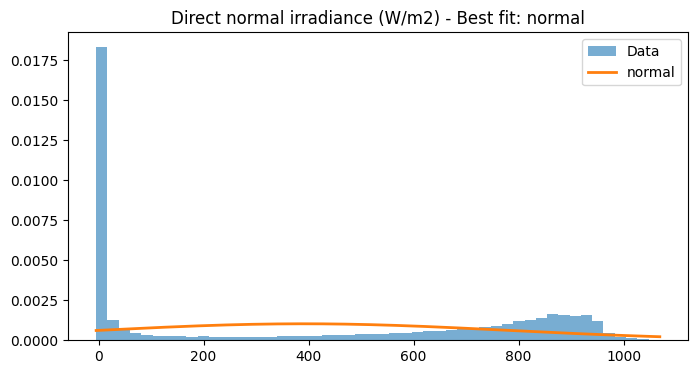

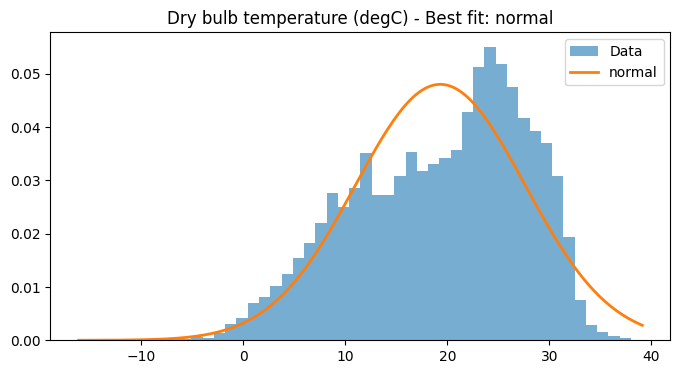

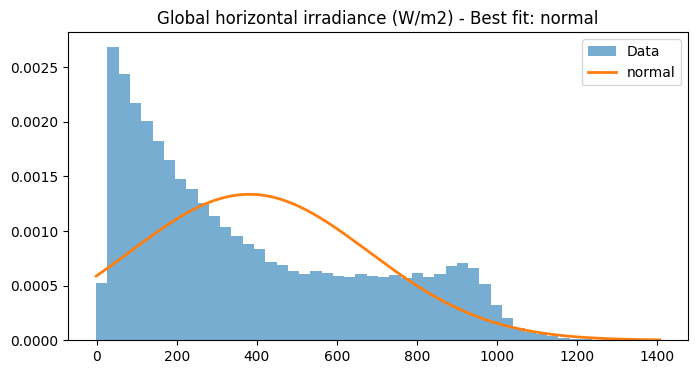

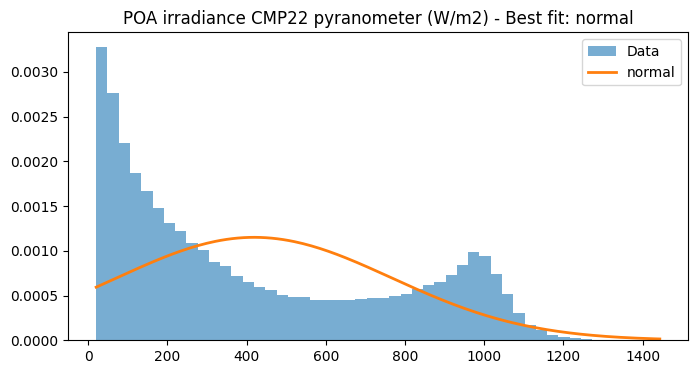

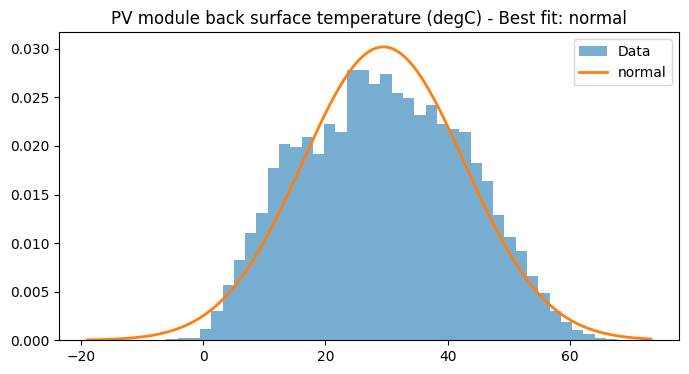

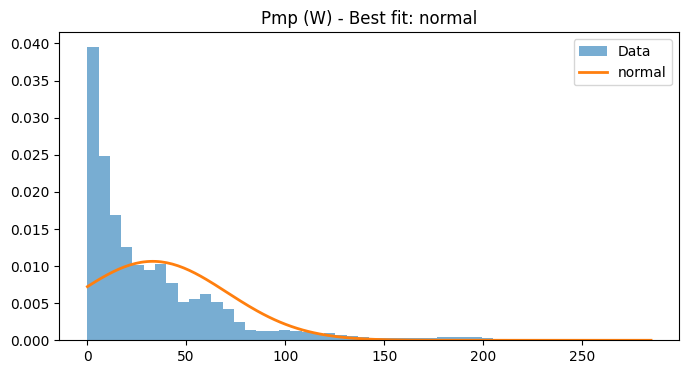

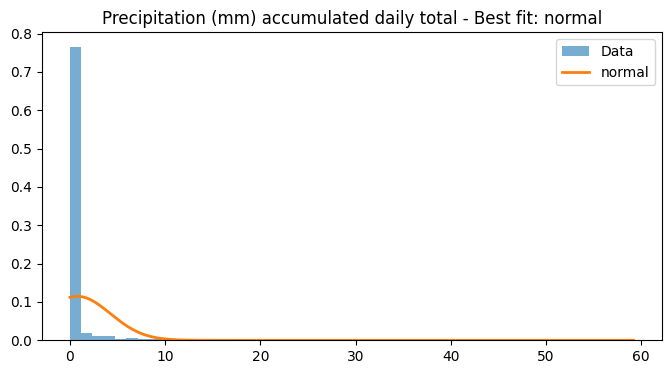

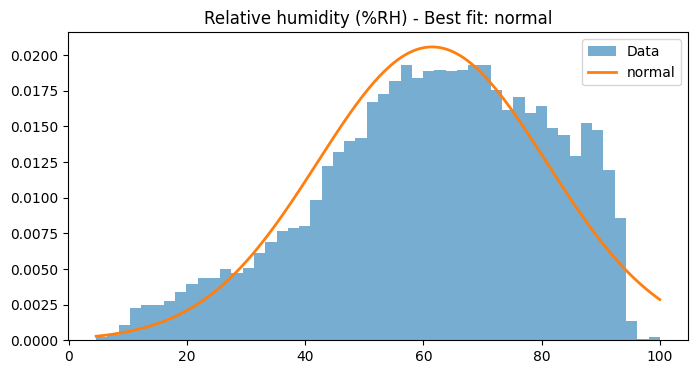

In [ ]:
# =========================================
# 1. LIBRERÍAS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================================
# 2. LIMPIEZA DE DATOS
# =========================================

df_clean = dataset_total.select_dtypes(include=[np.number])

print("Columnas numéricas utilizadas:")
print(df_clean.columns)

# eliminar columnas con muchos NaN
df_clean = df_clean.dropna(axis=1, thresh=len(df_clean)*0.5)

# =========================================
# 3. ANÁLISIS DE DISTRIBUCIONES
# =========================================

results = []

# Mapeo correcto de distribuciones
dist_map = {
    "normal": ("norm", stats.norm),
    "exponential": ("expon", stats.expon),
    "uniform": ("uniform", stats.uniform),
    "laplace": ("laplace", stats.laplace),
    "cauchy": ("cauchy", stats.cauchy),
    "gamma": ("gamma", stats.gamma),
    "lognormal": ("lognorm", stats.lognorm)
}

for col in df_clean.columns:

    data = df_clean[col].dropna()

    if len(data) < 10 or data.std() == 0:
        continue

    print(f"\n===== VARIABLE: {col} =====")

    best_p = -1
    best_dist = None

    for name, (scipy_name, dist_obj) in dist_map.items():

        # Condiciones para gamma/lognormal
        if name in ["gamma", "lognormal"] and not np.all(data > 0):
            continue

        try:
            # Ajuste de parámetros
            params = dist_obj.fit(data)

            # KS test
            ks_stat, ks_p = stats.kstest(data, scipy_name, args=params)

            print(f"{name:<10} -> KS={ks_stat:.4f}, p={ks_p:.4e}")

            results.append({
                "variable": col,
                "distribution": name,
                "ks_stat": ks_stat,
                "p_value": ks_p
            })

            # mejor distribución
            if ks_p > best_p:
                best_p = ks_p
                best_dist = name

        except Exception as e:
            print(f"{name:<10} -> error: {e}")

    print(f" Mejor distribución: {best_dist} (p={best_p:.4e})")

# =========================================
# 4. TABLA FINAL
# =========================================

df_results = pd.DataFrame(results)

df_best = df_results.loc[df_results.groupby("variable")["p_value"].idxmax()].copy()

df_best["fit_quality"] = df_best["p_value"].apply(
    lambda p: "Good fit" if p >= 0.05 else "Poor fit"
)

print("\n===== MEJOR DISTRIBUCIÓN POR VARIABLE =====")
print(df_best)

# =========================================
# 5. VISUALIZACIÓN CORREGIDA
# =========================================

for col in df_best["variable"]:

    data = df_clean[col].dropna()

    plt.figure(figsize=(8,4))

    # histograma
    plt.hist(data, bins=50, density=True, alpha=0.6, label="Data")

    best_dist_name = df_best[df_best["variable"] == col]["distribution"].values[0]

    scipy_name, dist_obj = dist_map[best_dist_name]

    try:
        params = dist_obj.fit(data)

        x = np.linspace(data.min(), data.max(), 200)
        y = dist_obj.pdf(x, *params)

        plt.plot(x, y, linewidth=2, label=best_dist_name)

    except:
        pass

    plt.title(f"{col} - Best fit: {best_dist_name}")
    plt.legend()
    plt.show()

Parques: ['Eugene' 'Cocoa' 'Golden']


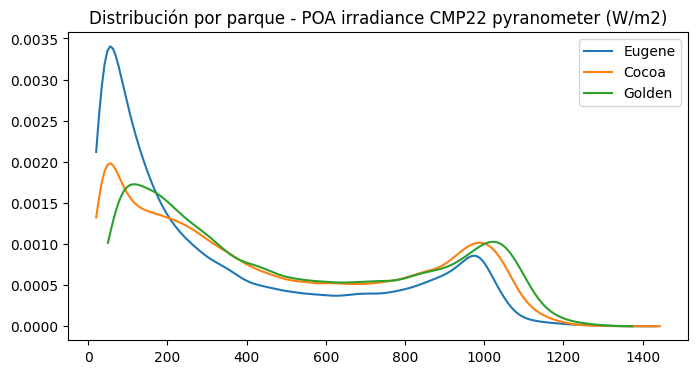

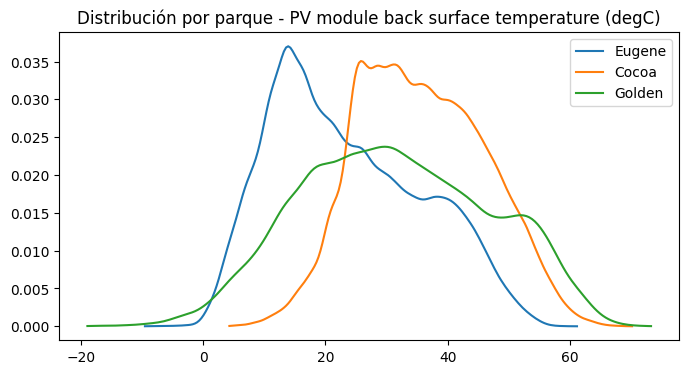

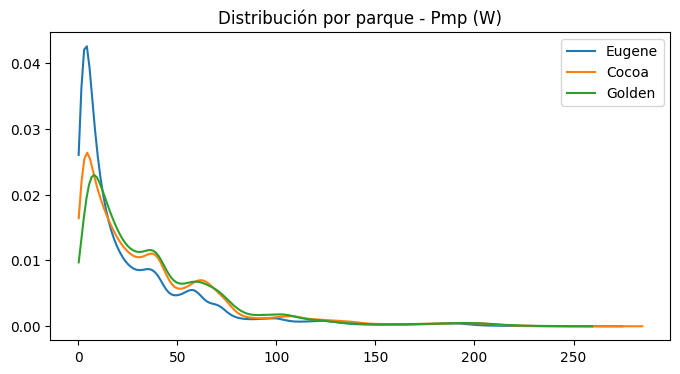

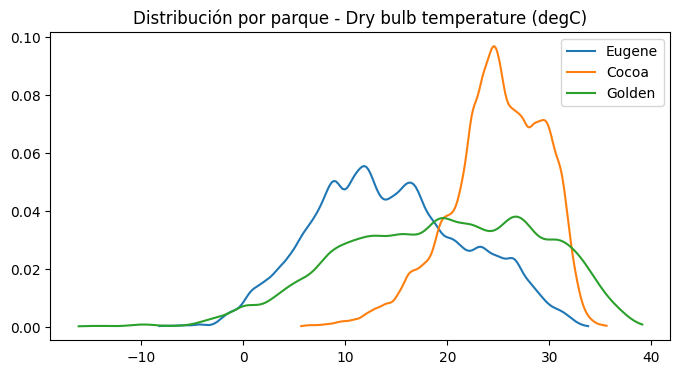

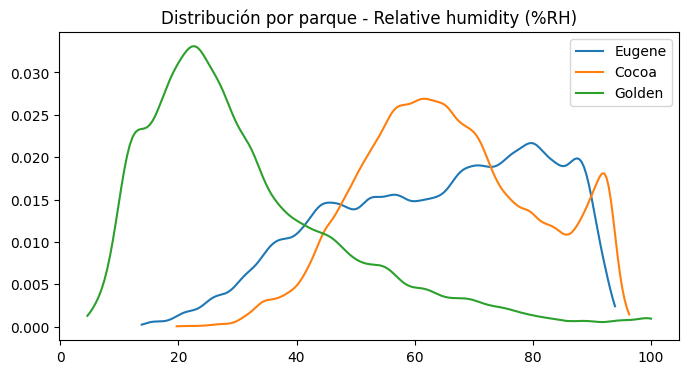

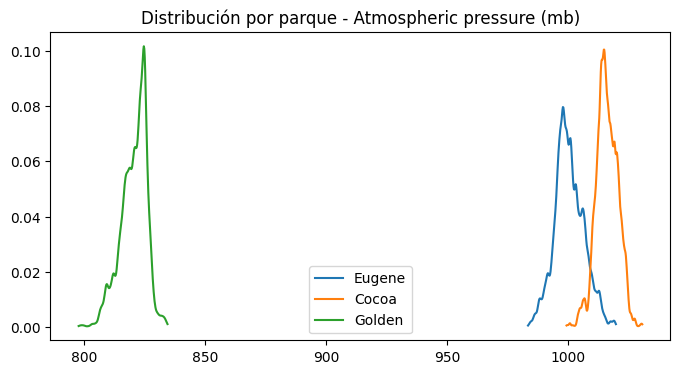

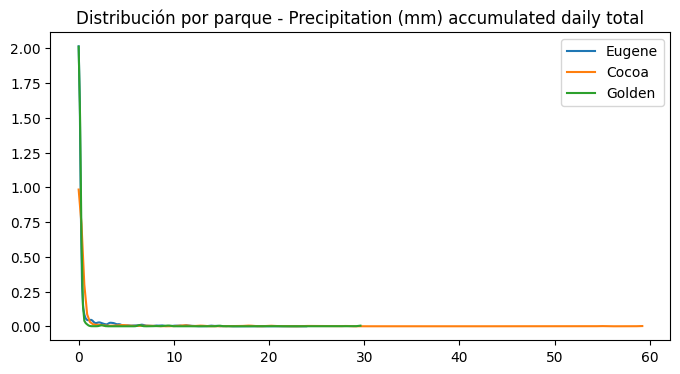

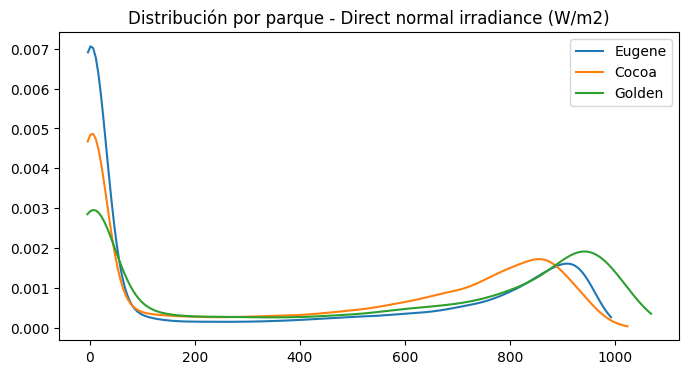

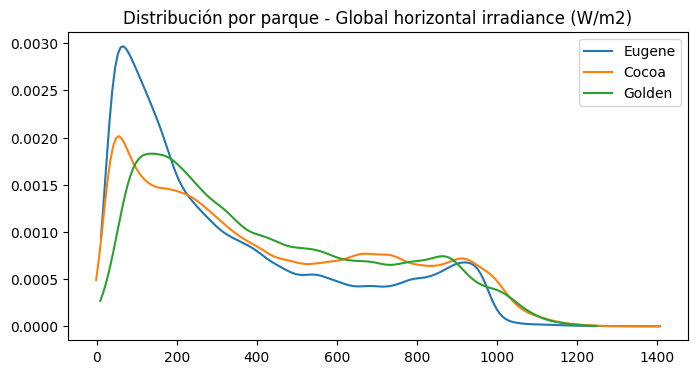

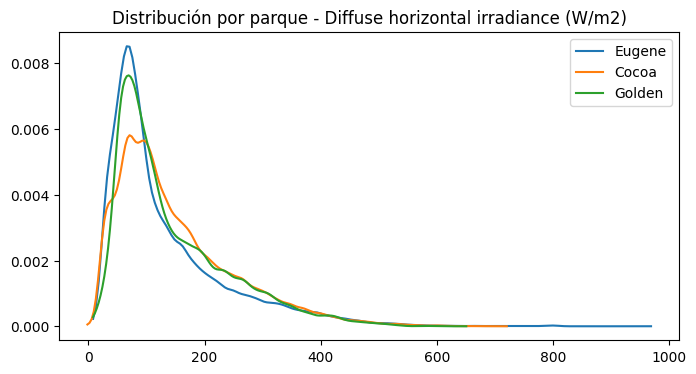

In [ ]:
# =========================================
# 1. LIMPIEZA
# =========================================

df = dataset_total.copy()

# eliminar -9999
df = df.replace(-9999, np.nan)

# solo columnas numéricas + parque
df_clean = df.select_dtypes(include=[np.number])
df_clean["parque_id"] = df["parque_id"]

# =========================================
# 2. VARIABLES Y PARQUES
# =========================================

variables = [col for col in df_clean.columns if col != "parque_id"]
parques = df_clean["parque_id"].unique()

print("Parques:", parques)

# =========================================
# 3. GRAFICAR DISTRIBUCIONES
# =========================================

for var in variables:

    plt.figure(figsize=(8,4))

    for parque in parques:

        data = df_clean[df_clean["parque_id"] == parque][var].dropna()

        if len(data) < 50:
            continue

        # KDE (mejor que hist para comparar)
        density = stats.gaussian_kde(data)

        x = np.linspace(data.min(), data.max(), 200)
        y = density(x)

        plt.plot(x, y, label=parque)

    plt.title(f"Distribución por parque - {var}")
    plt.legend()
    plt.show()

# 3. MODELO BASELINE

No ignoramos el parque y el panel, solo el timestamp.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_parque = LabelEncoder()
le_panel  = LabelEncoder()

dataset_total["parque_enc"] = le_parque.fit_transform(dataset_total["parque_id"])
dataset_total["panel_enc"]  = le_panel.fit_transform(dataset_total["panel_id"])

In [ ]:
df_model=dataset_total.drop(columns=["parque_id","panel_id"])

In [ ]:
df_model.describe()

,POA irradiance CMP22 pyranometer (W/m2),PV module back surface temperature (degC),Pmp (W),Dry bulb temperature (degC),Relative humidity (%RH),Atmospheric pressure (mb),Precipitation (mm) accumulated daily total,Direct normal irradiance (W/m2),Global horizontal irradiance (W/m2),Diffuse horizontal irradiance (W/m2),parque_enc,panel_enc
count,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000
mean,419.073269,29.467554,33.109488,19.317690,61.454120,989.396137,0.769051,390.631045,380.965122,141.156003,0.672666,10.427807
std,346.843670,13.214163,37.509871,8.305093,19.398323,56.567985,3.476576,387.059795,298.460348,102.224197,0.646279,6.028548
min,19.900000,-18.900000,0.139500,-16.100000,4.600000,797.900000,0.000000,-4.700000,-1.700000,-1.700000,0.000000,0.000000
25%,112.900000,19.300000,6.666200,12.900000,48.800000,997.600000,0.000000,0.900000,125.400000,67.900000,0.000000,4.000000
50%,295.100000,29.300000,20.023850,20.700000,62.900000,1006.300000,0.000000,299.600000,288.000000,107.800000,1.000000,10.000000
75%,733.200000,39.500000,46.096500,25.900000,76.600000,1015.000000,0.000000,802.400000,612.300000,187.200000,1.000000,15.000000
max,1443.500000,73.200000,284.718900,39.100000,100.000000,1030.700000,59.200000,1069.000000,1406.600000,969.000000,2.000000,21.000000


In [ ]:
X = df_model.drop(columns=["Pmp (W)"])
y = df_model["Pmp (W)"]

In [ ]:
from sklearn.model_selection import train_test_split

# Primero separar test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Luego separar val del resto (20% del total = 25% de train_val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

# Resultado: 60% train, 20% val, 20% test
print(X_train.shape, X_val.shape, X_test.shape)

(577464, 11) (192488, 11) (192488, 11)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import numpy as np

np.mean(X_train_scaled, axis=0)


array([ 3.39605231e-17, -3.17850809e-16, -1.64450142e-16, -1.28287106e-16,
        7.57366422e-15,  1.04748526e-16,  1.07270957e-16, -4.93658039e-17,
       -6.91022818e-17,  1.60205076e-17,  9.95190981e-17])

In [ ]:
np.std(X_train_scaled, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

## A. DISEÑO DEL MODELO

In [ ]:
import torch
import torch.nn as nn

class PVModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(11, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
class PVModelV2(nn.Module):

    def __init__(self, input_size=11):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
model = PVModel()
print(model)

model2 = PVModelV2()
print(model2)

PVModel(
  (model): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)
PVModelV2(
  (model): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_feature

In [ ]:
model(X_train_tensor[:5])

tensor([[0.0893],
        [0.0890],
        [0.0805],
        [0.0772],
        [0.0373]], grad_fn=<AddmmBackward0>)

In [ ]:
model2(X_train_tensor[:5])

tensor([[ 0.0059],
        [-0.4352],
        [ 0.2278],
        [-0.0804],
        [ 0.1537]], grad_fn=<AddmmBackward0>)

In [ ]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1024
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024
)

## B. ML FLOW

In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 116.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 21.4 MB/s eta 0:00:00


In [ ]:
import mlflow

In [ ]:
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("PV_Power_Final")

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/23 13:03:53 INFO mlflow.tracking.fluent: Experiment with name 'PV_Power_Final' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///content/mlruns/820085705089959661', creation_time=1774271033904, experiment_id='820085705089959661', last_update_time=1774271033904, lifecycle_stage='active', name='PV_Power_Final', tags={}, workspace='default'>

In [ ]:
class PVModel(nn.Module):

    def __init__(self, layers_sizes, input_size=11):
        super().__init__()

        layers = []

        for size in layers_sizes:
            layers.append(nn.Linear(input_size, size))
            layers.append(nn.ReLU())
            input_size = size

        layers.append(nn.Linear(input_size, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [ ]:
class PVModelV2(nn.Module):

    def __init__(self, layers_sizes,dropout, input_size=11):
        super().__init__()

        layers = []

        for size in layers_sizes:
            layers.append(nn.Linear(input_size, size))
            layers.append(nn.BatchNorm1d(size))   # nuevo
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))         # nuevo
            input_size = size

        layers.append(nn.Linear(input_size, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [ ]:
def evaluate(model, loader, criterion):

    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
import torch
import torch.nn as nn
import mlflow
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# =========================================
# EVALUACIÓN COMPLETA
# =========================================
def evaluate_metrics(model, loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for X_batch, y_batch in loader:

            preds = model(X_batch)

            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return mse, rmse, mae, r2


# =========================================
# TRAIN CON TRACKING
# =========================================
def train_model(arch, lr, epochs, model, dropout=0):

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    patience = 5
    counter = 0

    with mlflow.start_run():

        # PARAMS
        mlflow.log_param("arquitectura", str(arch))
        mlflow.log_param("lr", lr)
        mlflow.log_param("dropout", dropout)

        for epoch in range(epochs):

            # ======================
            # TRAIN
            # ======================
            model.train()
            total_loss = 0

            for X_batch, y_batch in train_loader:

                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()

            train_loss = total_loss / len(train_loader)

            # ======================
            # VALIDACIÓN
            # ======================
            val_loss = evaluate(model, val_loader, criterion)

            # ======================
            # MÉTRICAS COMPLETAS
            # ======================
            train_mse, train_rmse, train_mae, train_r2 = evaluate_metrics(model, train_loader)
            val_mse, val_rmse, val_mae, val_r2 = evaluate_metrics(model, val_loader)

            # ======================
            # LOGGING MLFLOW
            # ======================
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("val_loss", val_loss, step=epoch)

            mlflow.log_metric("train_rmse", train_rmse, step=epoch)
            mlflow.log_metric("val_rmse", val_rmse, step=epoch)

            mlflow.log_metric("train_mae", train_mae, step=epoch)
            mlflow.log_metric("val_mae", val_mae, step=epoch)

            mlflow.log_metric("train_r2", train_r2, step=epoch)
            mlflow.log_metric("val_r2", val_r2, step=epoch)

            print(f"""
Epoch {epoch+1}
Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}
Val RMSE: {val_rmse:.4f} | MAE: {val_mae:.4f} | R2: {val_r2:.4f}
""")

            # ======================
            # EARLY STOPPING
            # ======================
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), "best_model.pt")
                counter = 0
            else:
                counter += 1

            if counter >= patience:
                print(f"Early stopping en epoch {epoch+1}")
                break

        # ======================
        # LOG FINAL MODEL
        # ======================
        mlflow.pytorch.log_model(model, "model")

    return model

In [ ]:
arquitecturas = [
    [64, 32, 16],
    [128, 64, 32],
    [256, 128, 64]
]

learning_rates = [0.001, 0.0005]

dropouts = [0.1, 0.2]

epochs = 100

In [ ]:
for arch in arquitecturas:
    for lr in learning_rates:
        model = PVModel(arch)
        print(f"\nEntrenando modelo {arch} con lr={lr}")

        train_model(arch, lr, epochs,model)


Entrenando modelo [64, 32, 16] con lr=0.001

Epoch 1
Train Loss: 841.3348 | Val Loss: 530.3506
Val RMSE: 23.0292 | MAE: 13.9081 | R2: 0.6259


Epoch 2
Train Loss: 386.2938 | Val Loss: 277.3745
Val RMSE: 16.6545 | MAE: 10.3584 | R2: 0.8043


Epoch 3
Train Loss: 240.1550 | Val Loss: 206.0398
Val RMSE: 14.3541 | MAE: 8.5569 | R2: 0.8546


Epoch 4
Train Loss: 165.9230 | Val Loss: 125.7118
Val RMSE: 11.2121 | MAE: 6.5992 | R2: 0.9113


Epoch 5
Train Loss: 93.8799 | Val Loss: 70.2706
Val RMSE: 8.3828 | MAE: 4.9043 | R2: 0.9504


Epoch 6
Train Loss: 57.7730 | Val Loss: 49.2456
Val RMSE: 7.0175 | MAE: 3.9998 | R2: 0.9653


Epoch 7
Train Loss: 43.0241 | Val Loss: 38.1700
Val RMSE: 6.1782 | MAE: 3.5518 | R2: 0.9731


Epoch 8
Train Loss: 34.8880 | Val Loss: 31.4536
Val RMSE: 5.6084 | MAE: 3.2648 | R2: 0.9778


Epoch 9
Train Loss: 28.4743 | Val Loss: 25.6557
Val RMSE: 5.0652 | MAE: 2.9862 | R2: 0.9819


Epoch 10
Train Loss: 23.5521 | Val Loss: 21.6117
Val RMSE: 4.6489 | MAE: 2.7630 | R2: 0.9848



2026/03/23 13:21:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 13:21:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.



Epoch 69
Train Loss: 1.8748 | Val Loss: 1.8034
Val RMSE: 1.3429 | MAE: 0.8375 | R2: 0.9987

Early stopping en epoch 69


2026/03/23 13:21:54 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/23 13:22:05 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Entrenando modelo [64, 32, 16] con lr=0.0005

Epoch 1
Train Loss: 1002.2441 | Val Loss: 562.2641
Val RMSE: 23.7120 | MAE: 14.6579 | R2: 0.6033


Epoch 2
Train Loss: 529.2637 | Val Loss: 487.0277
Val RMSE: 22.0686 | MAE: 13.4737 | R2: 0.6564


Epoch 3
Train Loss: 377.4337 | Val Loss: 289.1875
Val RMSE: 17.0055 | MAE: 10.5300 | R2: 0.7960


Epoch 4
Train Loss: 250.3601 | Val Loss: 227.9513
Val RMSE: 15.0980 | MAE: 8.8283 | R2: 0.8392


Epoch 5
Train Loss: 202.6032 | Val Loss: 181.9904
Val RMSE: 13.4904 | MAE: 7.8851 | R2: 0.8716


Epoch 6
Train Loss: 159.3156 | Val Loss: 140.5640
Val RMSE: 11.8560 | MAE: 6.9935 | R2: 0.9008


Epoch 7
Train Loss: 123.0163 | Val Loss: 109.4450
Val RMSE: 10.4616 | MAE: 6.1717 | R2: 0.9228


Epoch 8
Train Loss: 96.2806 | Val Loss: 86.2620
Val RMSE: 9.2877 | MAE: 5.6119 | R2: 0.9391


Epoch 9
Train Loss: 77.1377 | Val Loss: 69.6074
Val RMSE: 8.3431 | MAE: 5.0615 | R2: 0.9509


Epoch 10
Train Loss: 62.5042 | Val Loss: 57.5088
Val RMSE: 7.5835 | MAE: 4.6595 | 

...

2026/03/23 14:07:06 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Entrenando modelo [256, 128, 64] con lr=0.0005

Epoch 1
Train Loss: 705.9174 | Val Loss: 429.8560
Val RMSE: 20.7328 | MAE: 11.8484 | R2: 0.6968


Epoch 2
Train Loss: 278.7679 | Val Loss: 179.5920
Val RMSE: 13.4012 | MAE: 7.6372 | R2: 0.8733


Epoch 3
Train Loss: 117.6045 | Val Loss: 70.0833
Val RMSE: 8.3716 | MAE: 4.5928 | R2: 0.9506


Epoch 4
Train Loss: 49.3162 | Val Loss: 37.1785
Val RMSE: 6.0974 | MAE: 3.0748 | R2: 0.9738


Epoch 5
Train Loss: 28.0964 | Val Loss: 20.7748
Val RMSE: 4.5580 | MAE: 2.3488 | R2: 0.9853


Epoch 6
Train Loss: 14.0572 | Val Loss: 10.1516
Val RMSE: 3.1862 | MAE: 1.5182 | R2: 0.9928


Epoch 7
Train Loss: 8.2617 | Val Loss: 7.6232
Val RMSE: 2.7610 | MAE: 1.3074 | R2: 0.9946


Epoch 8
Train Loss: 6.2846 | Val Loss: 5.7895
Val RMSE: 2.4061 | MAE: 1.1136 | R2: 0.9959


Epoch 9
Train Loss: 5.2107 | Val Loss: 4.8800
Val RMSE: 2.2091 | MAE: 1.0190 | R2: 0.9966


Epoch 10
Train Loss: 4.5298 | Val Loss: 4.4845
Val RMSE: 2.1177 | MAE: 1.0516 | R2: 0.9968


Epoch 11
T

2026/03/23 14:19:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 14:19:31 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/23 14:19:31 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Epoch 40
Train Loss: 1.0135 | Val Loss: 1.0477
Val RMSE: 1.0235 | MAE: 0.6065 | R2: 0.9993

Early stopping en epoch 40


2026/03/23 14:19:36 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


In [ ]:
for arch in arquitecturas:
    for lr in learning_rates:
        for dropout in dropouts:

            model = PVModelV2(arch, dropout=dropout)

            print(f"\nEntrenando modelo {arch} | lr={lr} | dropout={dropout}")

            train_model(arch, lr, epochs, model)


Entrenando modelo [64, 32, 16] | lr=0.001 | dropout=0.1

Epoch 1
Train Loss: 1859.9941 | Val Loss: 1057.3060
Val RMSE: 32.5162 | MAE: 21.3216 | R2: 0.2541


Epoch 2
Train Loss: 446.8705 | Val Loss: 102.6620
Val RMSE: 10.1322 | MAE: 6.7851 | R2: 0.9276


Epoch 3
Train Loss: 119.9756 | Val Loss: 46.8950
Val RMSE: 6.8480 | MAE: 4.1101 | R2: 0.9669


Epoch 4
Train Loss: 99.0740 | Val Loss: 36.1363
Val RMSE: 6.0114 | MAE: 4.0870 | R2: 0.9745


Epoch 5
Train Loss: 89.4992 | Val Loss: 27.9942
Val RMSE: 5.2910 | MAE: 3.1588 | R2: 0.9803


Epoch 6
Train Loss: 86.0382 | Val Loss: 38.8181
Val RMSE: 6.2304 | MAE: 3.7001 | R2: 0.9726


Epoch 7
Train Loss: 83.0026 | Val Loss: 28.5602
Val RMSE: 5.3442 | MAE: 3.0765 | R2: 0.9799


Epoch 8
Train Loss: 78.6803 | Val Loss: 31.6845
Val RMSE: 5.6289 | MAE: 3.2495 | R2: 0.9776


Epoch 9
Train Loss: 78.4637 | Val Loss: 28.3011
Val RMSE: 5.3199 | MAE: 3.3551 | R2: 0.9800



2026/03/23 14:22:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 14:22:52 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/23 14:22:52 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Epoch 10
Train Loss: 75.3085 | Val Loss: 28.8676
Val RMSE: 5.3729 | MAE: 3.0817 | R2: 0.9796

Early stopping en epoch 10


2026/03/23 14:22:57 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Entrenando modelo [64, 32, 16] | lr=0.001 | dropout=0.2

Epoch 1
Train Loss: 1993.1051 | Val Loss: 1164.0240
Val RMSE: 34.1177 | MAE: 22.4502 | R2: 0.1788


Epoch 2
Train Loss: 517.4203 | Val Loss: 112.7358
Val RMSE: 10.6177 | MAE: 7.2003 | R2: 0.9205


Epoch 3
Train Loss: 186.3049 | Val Loss: 62.7754
Val RMSE: 7.9231 | MAE: 5.2675 | R2: 0.9557


Epoch 4
Train Loss: 168.2121 | Val Loss: 48.6746
Val RMSE: 6.9767 | MAE: 4.4766 | R2: 0.9657


Epoch 5
Train Loss: 160.8287 | Val Loss: 43.5300
Val RMSE: 6.5977 | MAE: 4.1986 | R2: 0.9693


Epoch 6
Train Loss: 151.1372 | Val Loss: 50.4546
Val RMSE: 7.1031 | MAE: 4.3048 | R2: 0.9644


Epoch 7
Train Loss: 145.6565 | Val Loss: 36.3742
Val RMSE: 6.0311 | MAE: 3.9004 | R2: 0.9743


Epoch 8
Train Loss: 138.2244 | Val Loss: 40.6538
Val RMSE: 6.3760 | MAE: 4.0797 | R2: 0.9713


Epoch 9
Train Loss: 134.7441 | Val Loss: 39.5299
Val RMSE: 6.2873 | MAE: 4.0230 | R2: 0.9721


Epoch 10
Train Loss: 136.0113 | Val Loss: 28.3871
Val RMSE: 5.3279 | MAE: 3.4169

...

2026/03/23 14:44:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 14:44:27 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/23 14:44:27 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Epoch 36
Train Loss: 56.7848 | Val Loss: 7.7986
Val RMSE: 2.7926 | MAE: 1.8312 | R2: 0.9945

Early stopping en epoch 36


2026/03/23 14:44:33 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Entrenando modelo [64, 32, 16] | lr=0.0005 | dropout=0.2

Epoch 1
Train Loss: 2242.5721 | Val Loss: 2007.3461
Val RMSE: 44.8033 | MAE: 29.3512 | R2: -0.4161


Epoch 2
Train Loss: 1596.3368 | Val Loss: 1187.2867
Val RMSE: 34.4569 | MAE: 22.4641 | R2: 0.1624


Epoch 3
Train Loss: 783.2909 | Val Loss: 400.9771
Val RMSE: 20.0243 | MAE: 12.6083 | R2: 0.7171


Epoch 4
Train Loss: 334.8119 | Val Loss: 160.6788
Val RMSE: 12.6759 | MAE: 8.2579 | R2: 0.8866


Epoch 5
Train Loss: 217.1514 | Val Loss: 90.3566
Val RMSE: 9.5056 | MAE: 6.0570 | R2: 0.9363


Epoch 6
Train Loss: 195.6913 | Val Loss: 71.5285
Val RMSE: 8.4575 | MAE: 5.3945 | R2: 0.9495


Epoch 7
Train Loss: 187.0802 | Val Loss: 66.9124
Val RMSE: 8.1800 | MAE: 5.1678 | R2: 0.9528


Epoch 8
Train Loss: 179.6725 | Val Loss: 57.5098
Val RMSE: 7.5835 | MAE: 4.9782 | R2: 0.9594


Epoch 9
Train Loss: 173.5621 | Val Loss: 59.4632
Val RMSE: 7.7112 | MAE: 4.8272 | R2: 0.9581


Epoch 10
Train Loss: 169.1630 | Val Loss: 54.0950
Val RMSE: 7.3549 | M

KeyboardInterrupt: 

# MODELOS SIMPLES

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Entrenar modelo
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predicción
y_pred = lr_model.predict(X_val)

# Métricas
mse = mean_squared_error(y_val, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_val, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

In [ ]:
y_pred_nn = model(X_val_tensor).detach().numpy()

In [ ]:
mean_squared_error(y_val, y_pred_nn)

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Modelo
model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Entrenar
model.fit(X_train, y_train)

# Predecir
y_pred = model.predict(X_val)

# Métricas
mse = mean_squared_error(y_val, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_val, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

# 4. FEATURE ENGENIERING

Aquí sí quitamos los ids para tener un modelo escalable.

In [ ]:
mlflow.set_tracking_uri("file:./mlrunsfeatured")
mlflow.set_experiment("PV_Power_Final_Featured")

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/23 17:20:36 INFO mlflow.tracking.fluent: Experiment with name 'PV_Power_Final_Featured' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///content/mlrunsfeatured/606681307360651665', creation_time=1774286436025, experiment_id='606681307360651665', last_update_time=1774286436025, lifecycle_stage='active', name='PV_Power_Final_Featured', tags={}, workspace='default'>

In [ ]:
corr = df_model.corr(numeric_only=True)
corr["Pmp (W)"].sort_values(ascending=False)

,Pmp (W)
Pmp (W),1.000000
POA irradiance CMP22 pyranometer (W/m2),0.749594
Global horizontal irradiance (W/m2),0.705257
Direct normal irradiance (W/m2),0.618755
PV module back surface temperature (degC),0.563880
Dry bulb temperature (degC),0.232044
Diffuse horizontal irradiance (W/m2),0.154827
Atmospheric pressure (mb),-0.033946
parque_enc,-0.045844
Precipitation (mm) accumulated daily total,-0.107303


In [ ]:
df_model["physical_model"] = (
    df_model["POA irradiance CMP22 pyranometer (W/m2)"] *
    (1 - 0.004 * (df_model["PV module back surface temperature (degC)"] - 25))
)

In [ ]:
df_model = df_model[[
    "POA irradiance CMP22 pyranometer (W/m2)",
    "PV module back surface temperature (degC)",
    "physical_model",
    "Pmp (W)"
]]

In [ ]:
X = df_model.drop(columns=["Pmp (W)"])
y = df_model["Pmp (W)"]

In [ ]:
from sklearn.model_selection import train_test_split

# Primero separar test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Luego separar val del resto (20% del total = 25% de train_val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

# Resultado: 60% train, 20% val, 20% test
print(X_train.shape, X_val.shape, X_test.shape)

(577464, 3) (192488, 3) (192488, 3)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1024,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024
)

In [ ]:
for arch in arquitecturas:
    for lr in learning_rates:
        model = PVModel(arch)
        print(f"\nEntrenando modelo {arch} con lr={lr}")
        train_model(arch, lr, epochs,model)


Entrenando modelo [64, 32, 16] con lr=0.001

Epoch 1
Train Loss: 805.7680 | Val Loss: 486.8407
Val RMSE: 22.0646 | MAE: 13.3748 | R2: 0.6565


Epoch 2
Train Loss: 324.7255 | Val Loss: 194.6667
Val RMSE: 13.9523 | MAE: 8.6062 | R2: 0.8627


Epoch 3
Train Loss: 147.5355 | Val Loss: 115.4167
Val RMSE: 10.7431 | MAE: 6.4904 | R2: 0.9186


Epoch 4
Train Loss: 94.1803 | Val Loss: 79.6264
Val RMSE: 8.9234 | MAE: 5.5086 | R2: 0.9438


Epoch 5
Train Loss: 65.8061 | Val Loss: 58.4426
Val RMSE: 7.6448 | MAE: 4.5609 | R2: 0.9588


Epoch 6
Train Loss: 49.1801 | Val Loss: 42.0849
Val RMSE: 6.4873 | MAE: 3.9061 | R2: 0.9703


Epoch 7
Train Loss: 34.6012 | Val Loss: 29.1421
Val RMSE: 5.3983 | MAE: 3.2413 | R2: 0.9794


Epoch 8
Train Loss: 24.1784 | Val Loss: 19.8590
Val RMSE: 4.4563 | MAE: 2.6114 | R2: 0.9860


Epoch 9
Train Loss: 15.7809 | Val Loss: 13.2369
Val RMSE: 3.6382 | MAE: 2.0892 | R2: 0.9907


Epoch 10
Train Loss: 11.1515 | Val Loss: 9.9422
Val RMSE: 3.1531 | MAE: 1.7845 | R2: 0.9930


Epoc

2026/03/23 17:29:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 17:29:30 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.



Epoch 36
Train Loss: 1.5311 | Val Loss: 1.4974
Val RMSE: 1.2237 | MAE: 0.8000 | R2: 0.9989

Early stopping en epoch 36


2026/03/23 17:29:30 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/23 17:29:39 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Entrenando modelo [64, 32, 16] con lr=0.0005

Epoch 1
Train Loss: 1064.7373 | Val Loss: 560.8147
Val RMSE: 23.6814 | MAE: 14.4769 | R2: 0.6044


Epoch 2
Train Loss: 531.6796 | Val Loss: 510.8480
Val RMSE: 22.6022 | MAE: 13.3026 | R2: 0.6396


Epoch 3
Train Loss: 436.7564 | Val Loss: 368.6679
Val RMSE: 19.2007 | MAE: 11.0952 | R2: 0.7399


Epoch 4
Train Loss: 320.7653 | Val Loss: 290.8144
Val RMSE: 17.0533 | MAE: 10.2273 | R2: 0.7948


Epoch 5
Train Loss: 253.9741 | Val Loss: 228.1423
Val RMSE: 15.1043 | MAE: 9.0743 | R2: 0.8391


Epoch 6
Train Loss: 207.5753 | Val Loss: 191.1851
Val RMSE: 13.8271 | MAE: 8.3160 | R2: 0.8651


Epoch 7
Train Loss: 173.1197 | Val Loss: 158.0392
Val RMSE: 12.5714 | MAE: 7.4140 | R2: 0.8885


Epoch 8
Train Loss: 140.9508 | Val Loss: 127.3369
Val RMSE: 11.2844 | MAE: 6.5967 | R2: 0.9102


Epoch 9
Train Loss: 113.7446 | Val Loss: 101.6231
Val RMSE: 10.0809 | MAE: 5.7431 | R2: 0.9283


Epoch 10
Train Loss: 90.0672 | Val Loss: 80.7844
Val RMSE: 8.9880 | MAE: 5.

...

2026/03/23 18:24:33 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Entrenando modelo [256, 128, 64] con lr=0.0005

Epoch 1
Train Loss: 719.5324 | Val Loss: 501.7712
Val RMSE: 22.4000 | MAE: 12.8474 | R2: 0.6460


Epoch 2
Train Loss: 352.2754 | Val Loss: 182.8648
Val RMSE: 13.5227 | MAE: 7.8850 | R2: 0.8710


Epoch 3
Train Loss: 92.8282 | Val Loss: 49.3589
Val RMSE: 7.0256 | MAE: 4.0122 | R2: 0.9652


Epoch 4
Train Loss: 33.8338 | Val Loss: 22.9863
Val RMSE: 4.7944 | MAE: 2.4974 | R2: 0.9838


Epoch 5
Train Loss: 16.1447 | Val Loss: 10.8470
Val RMSE: 3.2935 | MAE: 1.7966 | R2: 0.9923


Epoch 6
Train Loss: 7.3817 | Val Loss: 5.2700
Val RMSE: 2.2956 | MAE: 1.2652 | R2: 0.9963


Epoch 7
Train Loss: 4.0330 | Val Loss: 3.1997
Val RMSE: 1.7888 | MAE: 1.0460 | R2: 0.9977


Epoch 8
Train Loss: 2.7003 | Val Loss: 2.4319
Val RMSE: 1.5595 | MAE: 0.9296 | R2: 0.9983


Epoch 9
Train Loss: 2.0593 | Val Loss: 1.8317
Val RMSE: 1.3534 | MAE: 0.8268 | R2: 0.9987


Epoch 10
Train Loss: 1.7609 | Val Loss: 1.5873
Val RMSE: 1.2598 | MAE: 0.7768 | R2: 0.9989


Epoch 11
Trai

2026/03/23 18:34:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 18:34:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/23 18:34:20 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Epoch 35
Train Loss: 0.9040 | Val Loss: 0.8946
Val RMSE: 0.9458 | MAE: 0.5709 | R2: 0.9994

Early stopping en epoch 35


2026/03/23 18:34:24 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


In [ ]:
for arch in arquitecturas:
    for lr in learning_rates:
        for dropout in dropouts:

            model = PVModelV2(arch, dropout=dropout)

            print(f"\nEntrenando modelo {arch} | lr={lr} | dropout={dropout}")

            train_model(arch, lr, epochs, model)


Entrenando modelo [64, 32, 16] | lr=0.001 | dropout=0.1

Epoch 1
Train Loss: 1964.1106 | Val Loss: 1201.9976
Val RMSE: 34.6699 | MAE: 23.3235 | R2: 0.1520


Epoch 2
Train Loss: 498.5485 | Val Loss: 126.3685
Val RMSE: 11.2414 | MAE: 7.1411 | R2: 0.9109


Epoch 3
Train Loss: 128.5298 | Val Loss: 45.7351
Val RMSE: 6.7628 | MAE: 4.3994 | R2: 0.9677


Epoch 4
Train Loss: 106.7225 | Val Loss: 27.4543
Val RMSE: 5.2397 | MAE: 3.4237 | R2: 0.9806


Epoch 5
Train Loss: 94.9125 | Val Loss: 27.8810
Val RMSE: 5.2803 | MAE: 3.3762 | R2: 0.9803


Epoch 6
Train Loss: 88.7789 | Val Loss: 35.6441
Val RMSE: 5.9703 | MAE: 3.6955 | R2: 0.9749


Epoch 7
Train Loss: 82.7405 | Val Loss: 22.6373
Val RMSE: 4.7579 | MAE: 3.0298 | R2: 0.9840


Epoch 8
Train Loss: 80.4582 | Val Loss: 28.0961
Val RMSE: 5.3005 | MAE: 3.1986 | R2: 0.9802


Epoch 9
Train Loss: 77.7483 | Val Loss: 25.2993
Val RMSE: 5.0298 | MAE: 3.1606 | R2: 0.9822


Epoch 10
Train Loss: 71.9819 | Val Loss: 15.0958
Val RMSE: 3.8854 | MAE: 2.5032 | R2:

2026/03/23 18:40:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 18:40:34 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/23 18:40:34 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Epoch 23
Train Loss: 58.4871 | Val Loss: 15.0865
Val RMSE: 3.8841 | MAE: 2.2883 | R2: 0.9894

Early stopping en epoch 23


2026/03/23 18:40:39 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Entrenando modelo [64, 32, 16] | lr=0.001 | dropout=0.2

Epoch 1
Train Loss: 1933.1389 | Val Loss: 1152.9082
Val RMSE: 33.9547 | MAE: 22.2082 | R2: 0.1867


Epoch 2
Train Loss: 499.2268 | Val Loss: 146.8164
Val RMSE: 12.1168 | MAE: 7.7388 | R2: 0.8964


Epoch 3
Train Loss: 190.5535 | Val Loss: 63.8569
Val RMSE: 7.9911 | MAE: 5.2994 | R2: 0.9550


Epoch 4
Train Loss: 168.9857 | Val Loss: 66.7312
Val RMSE: 8.1690 | MAE: 5.0011 | R2: 0.9529


Epoch 5
Train Loss: 158.6499 | Val Loss: 53.7265
Val RMSE: 7.3298 | MAE: 4.5819 | R2: 0.9621


Epoch 6
Train Loss: 151.8155 | Val Loss: 43.8143
Val RMSE: 6.6191 | MAE: 4.1508 | R2: 0.9691


Epoch 7
Train Loss: 146.4508 | Val Loss: 43.5248
Val RMSE: 6.5973 | MAE: 4.0431 | R2: 0.9693


Epoch 8
Train Loss: 141.6316 | Val Loss: 37.3546
Val RMSE: 6.1118 | MAE: 3.8419 | R2: 0.9736


Epoch 9
Train Loss: 137.2140 | Val Loss: 45.6249
Val RMSE: 6.7546 | MAE: 4.0463 | R2: 0.9678


Epoch 10
Train Loss: 133.6911 | Val Loss: 30.9593
Val RMSE: 5.5641 | MAE: 3.4830

...

2026/03/23 20:10:37 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Entrenando modelo [256, 128, 64] | lr=0.0005 | dropout=0.2

Epoch 1
Train Loss: 1720.3134 | Val Loss: 848.3070
Val RMSE: 29.1258 | MAE: 19.5538 | R2: 0.4015


Epoch 2
Train Loss: 395.3495 | Val Loss: 126.3275
Val RMSE: 11.2395 | MAE: 7.1879 | R2: 0.9109


Epoch 3
Train Loss: 166.2787 | Val Loss: 67.2651
Val RMSE: 8.2015 | MAE: 4.8346 | R2: 0.9525


Epoch 4
Train Loss: 131.2110 | Val Loss: 51.1017
Val RMSE: 7.1486 | MAE: 4.2918 | R2: 0.9639


Epoch 5
Train Loss: 109.5687 | Val Loss: 32.2311
Val RMSE: 5.6773 | MAE: 3.3828 | R2: 0.9773


Epoch 6
Train Loss: 94.4166 | Val Loss: 24.8167
Val RMSE: 4.9816 | MAE: 3.0759 | R2: 0.9825


Epoch 7
Train Loss: 82.8237 | Val Loss: 16.1695
Val RMSE: 4.0211 | MAE: 2.4182 | R2: 0.9886


Epoch 8
Train Loss: 73.6826 | Val Loss: 13.7582
Val RMSE: 3.7092 | MAE: 2.2840 | R2: 0.9903


Epoch 9
Train Loss: 67.5116 | Val Loss: 10.2813
Val RMSE: 3.2065 | MAE: 2.0038 | R2: 0.9927


Epoch 10
Train Loss: 63.5203 | Val Loss: 8.1854
Val RMSE: 2.8610 | MAE: 1.7863 | R

2026/03/23 20:19:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 20:19:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/23 20:19:38 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Epoch 24
Train Loss: 37.0469 | Val Loss: 3.2800
Val RMSE: 1.8111 | MAE: 1.0776 | R2: 0.9977

Early stopping en epoch 24


2026/03/23 20:19:43 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


In [ ]:
import shutil

shutil.make_archive('/content/mlrunsfeatured', 'zip', '/content/mlrunsfeatured')

'/content/mlrunsfeatured.zip'

In [ ]:
from google.colab import files
files.download('/content/mlrunsfeatured.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>